# Title Here

## Introduction

Lorem ipsum dolor sit amet, consectetur adipiscing elit. Aliquam justo massa, malesuada a lorem in, pellentesque tincidunt leo. Etiam lorem mauris, cursus non gravida id, facilisis interdum libero.

Sed arcu nisl, hendrerit vestibulum suscipit sed, feugiat eget mi. Fusce tincidunt ornare tellus, eu volutpat est tincidunt nec. Lorem ipsum dolor sit amet, consectetur adipiscing elit. 

Cras non ex eu risus mollis elementum. Suspendisse pulvinar massa non consequat blandit. Curabitur ultricies volutpat placerat.

## Table of Contents
- content 1
- content 2
- content 3
- content 4

***

## Asking Questions
1. How did average budgets change across eras?
2. Which genres survived/died each era?
3. Did mid-budget movies disappear?
4. Runtime Inflation
5. Seasonal release patterns

***

## Data Wrangling
Lorem ipsum dolor sit amet, consectetur adipiscing elit. Aliquam justo massa, malesuada a lorem in, pellentesque tincidunt leo. Etiam lorem mauris, cursus non gravida id, facilisis interdum libero.

In [28]:
# Import the libraries
import numpy as np
import pandas as pd
import scipy.stats as stats
import scikit_posthocs as sp
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load the dataset
df = pd.read_csv("C:\\Users\\raphk\\OneDrive\\Documents\\Portfolio\\DataAnalysisPython\\TMDB_2000-2025.csv")

### Assess the Data

In [2]:
# View the head of the dataset (first 5 rows)
df.head()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,budget,imdb_id,...,spoken_languages,cast,director,director_of_photography,writers,producers,music_composer,imdb_rating,imdb_votes,poster_path
0,8,Life in Loops (A Megacities RMX),7.200,30.0,Released,2006-01-01,0.0,80.0,42000.0,tt0825671,...,"English, हिन्दी, 日本語, Pусский, Español",NaN,Timo Novotny,Wolfgang Thaler,"Timo Novotny, Michael Glawogger","Timo Novotny, Ulrich Gehmacher",NaN,8.1,286.0,/7ln81BRnPR2wqxuITZxEciCe1lc.jpg
1,9,Sunday in August,6.800,28.0,Released,2004-09-02,0.0,15.0,0.0,tt0425473,...,Deutsch,"Rita Lengyel, Milton Welsh","Anna Haas, Marc Meyer",Peter Polsak-Lohmann,Marc Meyer,Marc Meyer,Christian Biegai,6.8,14.0,NaN
2,12,Finding Nemo,7.817,20113.0,Released,2003-05-30,940335536.0,100.0,94000000.0,tt0266543,...,English,"Nicholas Bird, Ben Stanton, Bob Peterson, Lisa...",Andrew Stanton,"Sharon Calahan, Jeremy Lasky","Bob Peterson, Adam Bronstein, Blake Tucker, Ji...","Graham Walters, John Lasseter",Thomas Newman,8.2,1188659.0,/eHuGQ10FUzK1mdOY69wF5pGgEf5.jpg
3,16,Dancer in the Dark,7.900,1917.0,Released,2000-09-01,40061153.0,140.0,12500000.0,tt0168629,...,English,"Edvin Karsson, Anna Norberg, Carol Linda Niels...",Lars von Trier,Robby Müller,"Sjón, Lars von Trier","Vibeke Windeløv, Leo Pescarolo, Peter Aalbæk J...",Björk,7.9,122724.0,/pWzOfTJRZHPNO1VNrMnNFqRcJwg.jpg
4,17,The Dark,5.700,288.0,Released,2005-09-28,6593579.0,87.0,0.0,tt0411267,...,"Cymraeg, English","Tonya Smith, Robin Griffith, Abigail Stone, Se...",John Fawcett,Christian Sebaldt,"Simon Maginn, Stephen Massicotte, Rory Gilmartin","Jeremy Bolt, Paul W. S. Anderson, Paul Tamasy,...",Edmund Butt,5.3,11813.0,/h6gCVAzjFLhzkffv2VZO1RgVCBt.jpg


In [3]:
# Get a summary of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 687685 entries, 0 to 687684
Data columns (total 28 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       687685 non-null  int64  
 1   title                    687681 non-null  object 
 2   vote_average             687685 non-null  float64
 3   vote_count               687685 non-null  float64
 4   status                   687685 non-null  object 
 5   release_date             687685 non-null  object 
 6   revenue                  687685 non-null  float64
 7   runtime                  687685 non-null  float64
 8   budget                   687685 non-null  float64
 9   imdb_id                  364279 non-null  object 
 10  original_language        687685 non-null  object 
 11  original_title           687681 non-null  object 
 12  overview                 590734 non-null  object 
 13  popularity               687685 non-null  float64
 14  tagl

### Handle Duplicates

In [4]:
# Check for duplicates
df.duplicated().sum()

np.int64(0)

There are no duplicate rows

### Handle Null Values

In [5]:
# To get the percentage of missing values in each column
df.isnull().sum()/len(df) * 100

id                          0.000000
title                       0.000582
vote_average                0.000000
vote_count                  0.000000
status                      0.000000
release_date                0.000000
revenue                     0.000000
runtime                     0.000000
budget                      0.000000
imdb_id                    47.028218
original_language           0.000000
original_title              0.000582
overview                   14.098170
popularity                  0.000000
tagline                    83.575329
genres                     23.784291
production_companies       54.303497
production_countries       37.835201
spoken_languages           34.645223
cast                       30.766557
director                   15.040607
director_of_photography    74.858693
writers                    50.245679
producers                  63.812938
music_composer             90.576209
imdb_rating                60.754415
imdb_votes                 60.754415
p

### Drop Columns

In [6]:
# Drop columns
df.drop(['imdb_id', 'original_title', 'status','overview', 'tagline', 'production_companies', 
         'production_countries', 'spoken_languages', 'cast', 'director', 'director_of_photography',
         'writers', 'producers', 'music_composer', 'imdb_rating', 'imdb_votes', 'poster_path'], axis=1, inplace=True)

### Correct Data types

In [7]:
df['release_date'] = pd.to_datetime(df['release_date'])

In [8]:
df.describe()

,id,vote_average,vote_count,release_date,revenue,runtime,budget,popularity
count,6.876850e+05,687685.000000,687685.000000,687685,6.876850e+05,687685.000000,6.876850e+05,687685.000000
mean,8.459624e+05,2.180342,28.421292,2016-08-28 21:46:23.106218496,9.273332e+05,45.337940,3.696170e+05,0.920645
min,8.000000e+00,0.000000,0.000000,2000-01-01 00:00:00,-1.200000e+01,0.000000,0.000000e+00,0.000000
25%,4.857930e+05,0.000000,0.000000,2011-10-21 00:00:00,0.000000e+00,4.000000,0.000000e+00,0.133900
50%,8.442350e+05,0.000000,0.000000,2018-02-07 00:00:00,0.000000e+00,22.000000,0.000000e+00,0.600000
75%,1.224960e+06,5.200000,1.000000,2022-08-26 00:00:00,0.000000e+00,85.000000,0.000000e+00,1.039400
max,1.604624e+06,10.000000,38458.000000,2025-12-26 00:00:00,2.923706e+09,14400.000000,5.839000e+08,562.748900
std,4.414688e+05,3.199354,422.095953,NaN,2.053764e+07,57.326196,5.688313e+06,2.413291


Since at least 50% of the data have budget equal to 0. We create a subset of the dataframe to only include movies with budget more than 0.

In [9]:
df_budget = df[df['budget'] > 0]
df_budget.describe()

,id,vote_average,vote_count,release_date,revenue,runtime,budget,popularity
count,5.567100e+04,55671.000000,55671.000000,55671,5.567100e+04,55671.000000,5.567100e+04,55671.000000
mean,8.740875e+05,3.091261,271.051265,2018-08-02 20:06:16.353936640,1.058239e+07,49.353487,4.565753e+06,1.457120
min,8.000000e+00,0.000000,0.000000,2000-01-01 00:00:00,-1.200000e+01,0.000000,1.000000e+00,0.000000
25%,4.346445e+05,0.000000,0.000000,2014-05-09 00:00:00,0.000000e+00,8.000000,4.200000e+02,0.122000
50%,9.720050e+05,0.000000,0.000000,2020-11-11 00:00:00,0.000000e+00,24.000000,6.000000e+03,0.600000
75%,1.317780e+06,6.300000,5.000000,2024-01-16 00:00:00,0.000000e+00,91.000000,4.000000e+05,1.409000
max,1.604621e+06,10.000000,38458.000000,2025-12-26 00:00:00,2.923706e+09,1265.000000,5.839000e+08,562.748900
std,5.056902e+05,3.572541,1444.930242,NaN,7.077332e+07,48.066725,1.950748e+07,5.033844


### Split by Eras

In [10]:
# Split the dataset into three eras
era1 = df_budget[df_budget['release_date'].dt.year <= 2010]
era2 = df_budget[(df_budget['release_date'].dt.year > 2010) & (df_budget['release_date'].dt.year <= 2019)]
era3 = df_budget[df_budget['release_date'].dt.year >= 2020]

In [11]:
era1.describe()

,id,vote_average,vote_count,release_date,revenue,runtime,budget,popularity
count,9.254000e+03,9254.000000,9254.000000,9254,9.254000e+03,9254.000000,9.254000e+03,9254.000000
mean,2.785940e+05,4.422488,632.633024,2006-08-01 08:56:13.589798912,2.328037e+07,84.635617,1.068393e+07,2.201268
min,8.000000e+00,0.000000,0.000000,2000-01-01 00:00:00,0.000000e+00,0.000000,1.000000e+00,0.000000
25%,1.658475e+04,2.000000,1.000000,2004-06-28 06:00:00,0.000000e+00,76.000000,2.500000e+04,0.566625
50%,5.598950e+04,5.400000,12.000000,2007-01-01 00:00:00,0.000000e+00,91.000000,1.000000e+06,1.352300
75%,3.743338e+05,6.453750,228.000000,2009-01-13 00:00:00,4.065664e+06,105.000000,8.000000e+06,2.999950
max,1.603768e+06,10.000000,38387.000000,2010-12-31 00:00:00,2.923706e+09,608.000000,4.200000e+08,121.808100
std,4.124170e+05,2.786278,2111.592509,NaN,8.745415e+07,40.747656,2.543225e+07,3.273784


In [12]:
era2.describe()

,id,vote_average,vote_count,release_date,revenue,runtime,budget,popularity
count,1.629100e+04,16291.000000,16291.000000,16291,1.629100e+04,16291.000000,1.629100e+04,16291.000000
mean,5.749122e+05,3.850414,457.118593,2016-02-14 23:59:28.178748928,1.639624e+07,64.200724,5.956783e+06,1.506718
min,1.890000e+02,0.000000,0.000000,2011-01-01 00:00:00,-1.200000e+01,0.000000,1.000000e+00,0.000000
25%,3.134510e+05,0.000000,0.000000,2013-12-21 12:00:00,0.000000e+00,14.000000,1.600000e+03,0.322800
50%,5.009150e+05,4.800000,1.000000,2016-06-01 00:00:00,0.000000e+00,79.000000,3.000000e+04,0.784400
75%,7.339360e+05,6.500000,27.000000,2018-05-31 00:00:00,0.000000e+00,99.000000,1.500000e+06,1.776150
max,1.604026e+06,10.000000,38458.000000,2019-12-31 00:00:00,2.799439e+09,1265.000000,4.899000e+08,77.574400
std,3.705336e+05,3.353208,1982.864761,NaN,9.334240e+07,47.985176,2.249107e+07,2.320104


In [13]:
era3.describe()

,id,vote_average,vote_count,release_date,revenue,runtime,budget,popularity
count,3.012600e+04,30126.000000,30126.000000,30126,3.012600e+04,30126.000000,3.012600e+04,30126.000000
mean,1.218792e+06,2.271818,59.363673,2023-08-10 05:46:49.878510080,3.537958e+06,30.486822,1.934178e+06,1.201714
min,5.492000e+03,0.000000,0.000000,2020-01-01 00:00:00,0.000000e+00,0.000000,1.000000e+00,0.000000
25%,1.042452e+06,0.000000,0.000000,2022-06-06 00:00:00,0.000000e+00,5.000000,1.500000e+02,0.066800
50%,1.266738e+06,0.000000,0.000000,2023-11-17 00:00:00,0.000000e+00,13.000000,1.438000e+03,0.432350
75%,1.435859e+06,5.500000,1.000000,2024-12-08 00:00:00,0.000000e+00,39.000000,1.200000e+04,0.994525
max,1.604621e+06,10.000000,21376.000000,2025-12-26 00:00:00,2.353096e+09,999.000000,5.839000e+08,562.748900
std,2.644268e+05,3.686929,508.826721,NaN,4.558702e+07,40.704952,1.454494e+07,6.355100


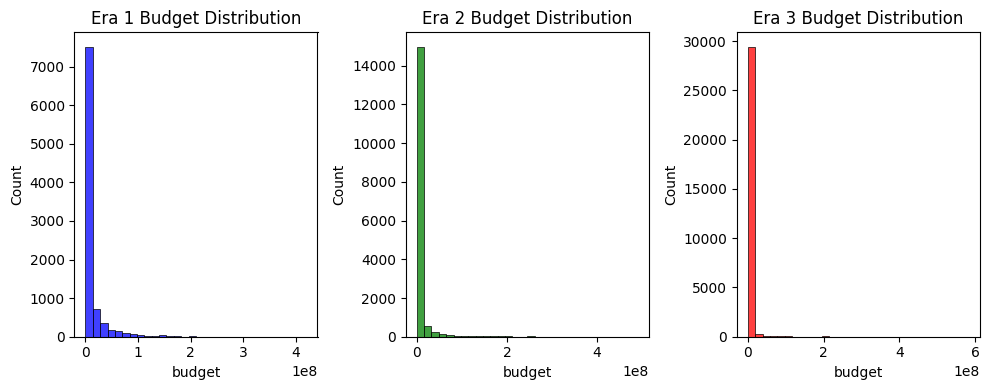

In [30]:
# Visualize the budget distributions for each era
fig, axs = plt.subplots(1, 3, figsize=(10, 4))
sns.histplot(x="budget", data=era1, ax=axs[0], color='blue', bins=30)
axs[0].set_title('Era 1 Budget Distribution')
sns.histplot(x="budget", data=era2, ax=axs[1], color='green', bins=30)
axs[1].set_title('Era 2 Budget Distribution')
sns.histplot(x="budget", data=era3, ax=axs[2], color='red', bins=30)
axs[2].set_title('Era 3 Budget Distribution')
plt.tight_layout()
plt.show()

## Q1: How did average budgets change across eras?

### Check for ANOVA Assumptions

**Normality of Residuals**: Since the data is very large N > 5000, the Shapiro-Wilk Normality Test may not be accurate, so the D'Agostino's K-squared test will be used instead. This tests the null hypothesis that the data is normally distributed. We reject the null hypothesis if p-value < 0.05.

**Homogeneity of Variance**: We can formally test the homogeneity of variances using the Levene’s Test. This tests the null hypothesis that variances are homogeneous. We reject the null hypothesis if p-value < 0.05.

In [14]:
# Normality Test
k2, normality_p_value = stats.normaltest(np.concatenate([era1['budget'], era2['budget'], era3['budget']]))

# Levene's Test for Homogeneity of Variance
levene_stat, levene_p_value = stats.levene(era1['budget'], era2['budget'], era3['budget'])

print("Normality Test p-value:", normality_p_value)
print("Levene's Test p-value:", levene_p_value)

Normality Test p-value: 0.0
Levene's Test p-value: 0.0


### Hypothesis Testing using Kruskal Wallis Test

Since the assumptions of ANOVA are violated, we perform hypothesis testing on the non-parametric test: **Kruskal Wallis Test**.

$H_0$: The budgets across eras remain the same

$H_a$: There is at least one era that has a budget significantly different from the other eras.

In [15]:
# Kruskal-Wallis H-test
kw_stat, kw_p_value = stats.kruskal(era1['budget'], era2['budget'], era3['budget'])
print("Kruskal-Wallis H-test p-value:", kw_p_value)

Kruskal-Wallis H-test p-value: 0.0


### Post-hoc Analysis using Mann-Whitney Pairwise Test 
Since p-value < 0.05, we reject the null hypothesis. We conduct the post-hoc analysis using the **Mann-Whitney pairwise** test.

In [16]:
# The pairwise p-values using Mann-Whitney U test with Bonferroni correction
posthoc = sp.posthoc_mannwhitney([era1['budget'], era2['budget'], era3['budget']], p_adjust='bonferroni')
print(posthoc)

     1    2    3
1  1.0  0.0  0.0
2  0.0  1.0  0.0
3  0.0  0.0  1.0


In [26]:
# Compute the median budgets for each era
medians = [era1['budget'].median(), era2['budget'].median(), era3['budget'].median()]
average = [era1['budget'].mean(), era2['budget'].mean(), era3['budget'].mean()]
print("Median Budget Era 1:", medians[0])
print("Median Budget Era 2:", medians[1])
print("Median Budget Era 3:", medians[2])

Median Budget Era 1: 1000000.0
Median Budget Era 2: 30000.0
Median Budget Era 3: 1438.0


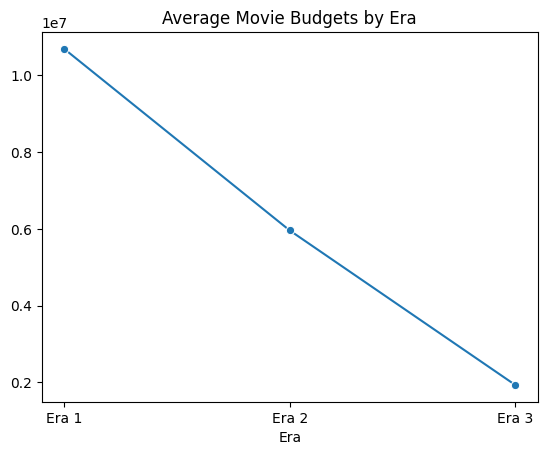

In [ ]:
# Plot the average budgets
ax = sns.lineplot(x=['Era 1', 'Era 2', 'Era 3'], y=average, marker='o')
plt.title('Average Movie Budgets by Era')
plt.xlabel('Era')
  
plt.show()